In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


## 1. Import Library

Blok kode ini mengimpor pustaka yang diperlukan pandas untuk manipulasi data, numpy untuk operasi numerik, matplotlib untuk visualisasi, serta modul dari scikit-learn untuk preprocessing, pemodelan, dan evaluasi.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import joblib

## 2. Load Dataset

Membaca file CSV dataset yang telah diunggah.

In [3]:
# Ganti path jika file berada pada lokasi lain
path = "/content/gdrive/MyDrive/machine learning/praktikum/praktikum9"
df = pd.read_csv(path + "/data/data.csv", sep=",")
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


## 3. Cek Struktur Dataset

Lihat ringkasan dataset untuk mengetahui tipe kolom dan apakah terdapat missing value.

In [4]:
# Menampilkan informasi ringkasan dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

## 4. Hapus Kolom Tidak Relevan

Hapus kolom `id` dan kolom kosong `Unnamed: 32` jika ada, karena tidak berguna untuk pemodelan.

In [6]:
# Menghapus kolom yang tidak relevan
df = df.drop(columns=['id', 'Unnamed: 32'], errors='ignore')
print("Shape setelah drop:", df.shape)
df.head()

Shape setelah drop: (569, 31)


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## 5. Encoding Label (diagnosis)

Ubah label diagnosis: 'M' (malignant) menjadi 1 dan 'B' (benign) menjadi 0 agar bisa dipelajari model.

In [7]:
# Encoding Diagnosis
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})
print("Distribusi label (diagnosis):")
print(df['diagnosis'].value_counts())

Distribusi label (diagnosis):
diagnosis
0    357
1    212
Name: count, dtype: int64


## 6. Pisahkan Fitur (X) dan Label (y)

X = semua kolom kecuali 'diagnosis'. y = kolom 'diagnosis'.

In [8]:
# Memisahkan fitur dan target
X = df.drop(columns=['diagnosis'])
y = df['diagnosis']
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (569, 30)
y shape: (569,)


## 7. Split Data (Train/Test)

Membagi data menjadi 80% untuk training dan 20% untuk testing. Menggunakan `stratify=y` agar proporsi kelas tetap seimbang.

In [9]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train shapes:", X_train.shape, y_train.shape)
print("Test shapes: ", X_test.shape, y_test.shape)

Train shapes: (455, 30) (455,)
Test shapes:  (114, 30) (114,)


## 8. Scaling (Standardization)

StandardScaler membuat setiap fitur memiliki mean 0 dan standard deviation 1. Ini penting terutama untuk model yang sensitif pada skala fitur.

In [10]:
# Standarisasi fitur numerik
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Sample scaled features (first 5 rows):")
print(X_train_scaled[:5])

Sample scaled features (first 5 rows):
[[ 5.18558727e-01  8.91825791e-01  4.24631702e-01  3.83925436e-01
  -9.74743706e-01 -6.89771505e-01 -6.88586446e-01 -3.98175254e-01
  -1.03915470e+00 -8.25056321e-01 -1.09317755e-01 -5.59755400e-02
  -2.10096206e-01 -1.59132582e-02 -1.00518399e+00 -9.11941990e-01
  -6.62815884e-01 -6.52561081e-01 -7.01889114e-01 -2.75393571e-01
   5.79797697e-01  1.31324246e+00  4.66908134e-01  4.45982711e-01
  -5.96154777e-01 -6.34722227e-01 -6.10227299e-01 -2.35743918e-01
   5.45663235e-02  2.18367276e-02]
 [-5.16364088e-01 -1.63971029e+00 -5.41348716e-01 -5.42961327e-01
   4.76219058e-01 -6.31833818e-01 -6.04281166e-01 -3.03074908e-01
   5.21543093e-01 -4.54522896e-01 -6.04377961e-01 -1.00104604e+00
  -5.85429002e-01 -4.93453793e-01  4.03212009e-01 -7.68173276e-01
  -4.79187222e-01  1.14508478e-01 -1.42950761e-01 -5.77397732e-01
  -5.82458953e-01 -1.69029101e+00 -6.11934288e-01 -5.87013537e-01
   2.73581959e-01 -8.14844486e-01 -7.12666415e-01 -3.23207881e-01
  

## 9. Training Gaussian Naive Bayes

Membuat instance GaussianNB dan melatihnya menggunakan data training yang sudah distandarisasi.

In [11]:
# Training model Gaussian Naive Bayes
nb = GaussianNB()
nb.fit(X_train_scaled, y_train)

train_acc = nb.score(X_train_scaled, y_train)
print("Training accuracy:", train_acc)

Training accuracy: 0.945054945054945


## 10. Prediksi dan Evaluasi pada Data Uji

Melakukan prediksi pada data uji dan menghitung akurasi.

In [12]:
# Prediksi dan evaluasi
y_pred = nb.predict(X_test_scaled)
test_acc = accuracy_score(y_test, y_pred)
print("Testing accuracy :", test_acc)

Testing accuracy : 0.9210526315789473


## 11. Confusion Matrix

Menampilkan confusion matrix untuk melihat jumlah True Positive, True Negative, False Positive, dan False Negative.

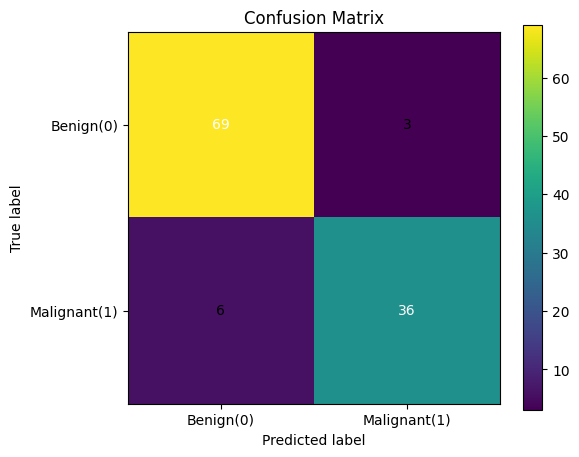

In [13]:
# Confusion matrix visualisasi menggunakan matplotlib
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.colorbar()
# Annotate each cell with counts
for (i, j), val in np.ndenumerate(cm):
    plt.text(j, i, int(val), ha='center', va='center', color='white' if val > cm.max()/2 else 'black')
plt.xticks([0,1], ["Benign(0)","Malignant(1)"])
plt.yticks([0,1], ["Benign(0)","Malignant(1)"])
plt.show()

## 12. Classification Report

Menampilkan precision, recall, f1-score untuk masing-masing kelas.

In [14]:
# Classification report (precision, recall, f1-score)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.96      0.94        72
           1       0.92      0.86      0.89        42

    accuracy                           0.92       114
   macro avg       0.92      0.91      0.91       114
weighted avg       0.92      0.92      0.92       114



## 13. Cross-Validation (5-fold)

Melakukan 5-fold cross-validation untuk menilai konsistensi performa model di beberapa subset data.

In [15]:
# Cross-validation pada seluruh dataset (memakai pipeline sederhana tanpa scaling leakage karena scaler hanya untuk numeric)
# Note: cross_val_score akan memanggil fit pada model beberapa kali; kita menggunakan X yang belum diskalakan di sini.
# Untuk pipeline yang benar-benar aman dari leakage sebaiknya menggunakan Pipeline yang menggabungkan scaler dan model.
from sklearn.pipeline import make_pipeline
pipeline = make_pipeline(StandardScaler(), GaussianNB())
cv_scores = cross_val_score(pipeline, X, y, cv=5)

print("CV scores:", cv_scores)
print("Mean CV accuracy:", cv_scores.mean())
print("Std CV accuracy:", cv_scores.std())

CV scores: [0.90350877 0.9122807  0.95614035 0.94736842 0.92035398]
Mean CV accuracy: 0.927930445582984
Std CV accuracy: 0.02035862995809893
